# Ranking Heuristics and Graph-Based Signals

## 1. Setup

### 1.1 Imports

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_ratings
from src.data.splitter import split_temporal
from src.data.adapter import DataAdapter
from src.models.base import BaseRecommender
from src.models.popularity import PopularityRecommender
from src.models.item_graph import ItemGraphRecommender
from src.models.pagerank import PersonalizedPageRankRecommender
from src.evaluation.metrics import compute_ranking_metrics, compute_beyond_accuracy_metrics

### 1.2 Constants

In [2]:
TRAIN_RATIO = 0.7
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
IMPLICIT_THRESHOLD = 4.0
TOP_K = 10

PAGERANK_DAMPING = 0.15
PAGERANK_ITERATIONS = 10

FIGURE_SIZE_SMALL = (8, 4)
FIGURE_SIZE_MEDIUM = (10, 6)
FIGURE_SIZE_LARGE = (12, 8)

COLOR_PRIMARY = "#4C72B0"
COLOR_SECONDARY = "#DD8452"
COLOR_TERTIARY = "#55A868"
COLOR_ACCENT = "#C44E52"

ARTIFACTS_DIRECTORY = Path('../artifacts')

### 1.3 Chart style

In [3]:
def configure_plot_style():
    plt.rcParams.update({
        'figure.dpi': 150,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 11,
        'axes.titlesize': 13,
        'axes.labelsize': 11,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
    })


configure_plot_style()

### 1.4 Data

In [4]:
ratings = load_ratings()

train_dataframe, validation_dataframe, test_dataframe = split_temporal(
    ratings,
    train_ratio=TRAIN_RATIO,
    validation_ratio=VALIDATION_RATIO,
    test_ratio=TEST_RATIO,
)

adapter = DataAdapter()
train_data = adapter.to_implicit(
    train_dataframe,
    threshold=IMPLICIT_THRESHOLD,
)

validation_positive = validation_dataframe[validation_dataframe['rating'] >= IMPLICIT_THRESHOLD]
validation_users = validation_positive['user_id'].unique()

pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'interactions': [len(train_dataframe), len(validation_dataframe), len(test_dataframe)],
    'positive': [
        train_data.X_ui.nnz,
        len(validation_positive),
        len(test_dataframe[test_dataframe['rating'] >= IMPLICIT_THRESHOLD]),
    ],
})

Loaded 1000209 ratings from c:\Users\Mykyta\Projects\ucu-recsys\experiments\..\data\ml-1m\ratings.dat


,split,interactions,positive
0,train,700118,416338
1,validation,150081,81113
2,test,150010,77830


## 2. Popularity-Based Ranking

### 2.1 Training

In [5]:
popularity_model = PopularityRecommender()
popularity_model.fit(train_data)

In [6]:
top_indices = popularity_model._popular_item_indices[:TOP_K]

pd.DataFrame({
    'rank': range(1, TOP_K + 1),
    'item_id': [train_data.idx_to_item[i] for i in top_indices],
    'interaction_count': [int(popularity_model._item_popularity[i]) for i in top_indices],
})

,rank,item_id,interaction_count
0,1,2858,2525
1,2,260,2230
2,3,1196,2173
3,4,2028,1956
4,5,1198,1914
5,6,593,1876
6,7,1210,1860
7,8,2571,1827
8,9,589,1758
9,10,527,1748


### 2.2 Evaluation

In [7]:
popularity_recommendations = popularity_model.recommend_for_eval(
    validation_users,
    k=TOP_K,
)

popularity_ranking = compute_ranking_metrics(
    validation_positive,
    popularity_recommendations,
    top_k=TOP_K,
)

popularity_beyond = compute_beyond_accuracy_metrics(
    train_dataframe,
    popularity_recommendations,
)

pd.DataFrame(
    list({**popularity_ranking, **popularity_beyond}.items()),
    columns=['metric', 'value'],
)

c:\Users\Mykyta\Projects\ucu-recsys\.venv\Lib\site-packages\recommenders\evaluation\python_evaluation.py:1435: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  avg_novelty = reco_item_novelty.agg({"product": "sum"})[0] / n_recommendations


,metric,value
0,ndcg,0.076190
1,map,0.036509
2,precision,0.064215
3,recall,0.050457
4,coverage,0.030693
5,novelty,8.365292


### 2.3 Popularity distribution

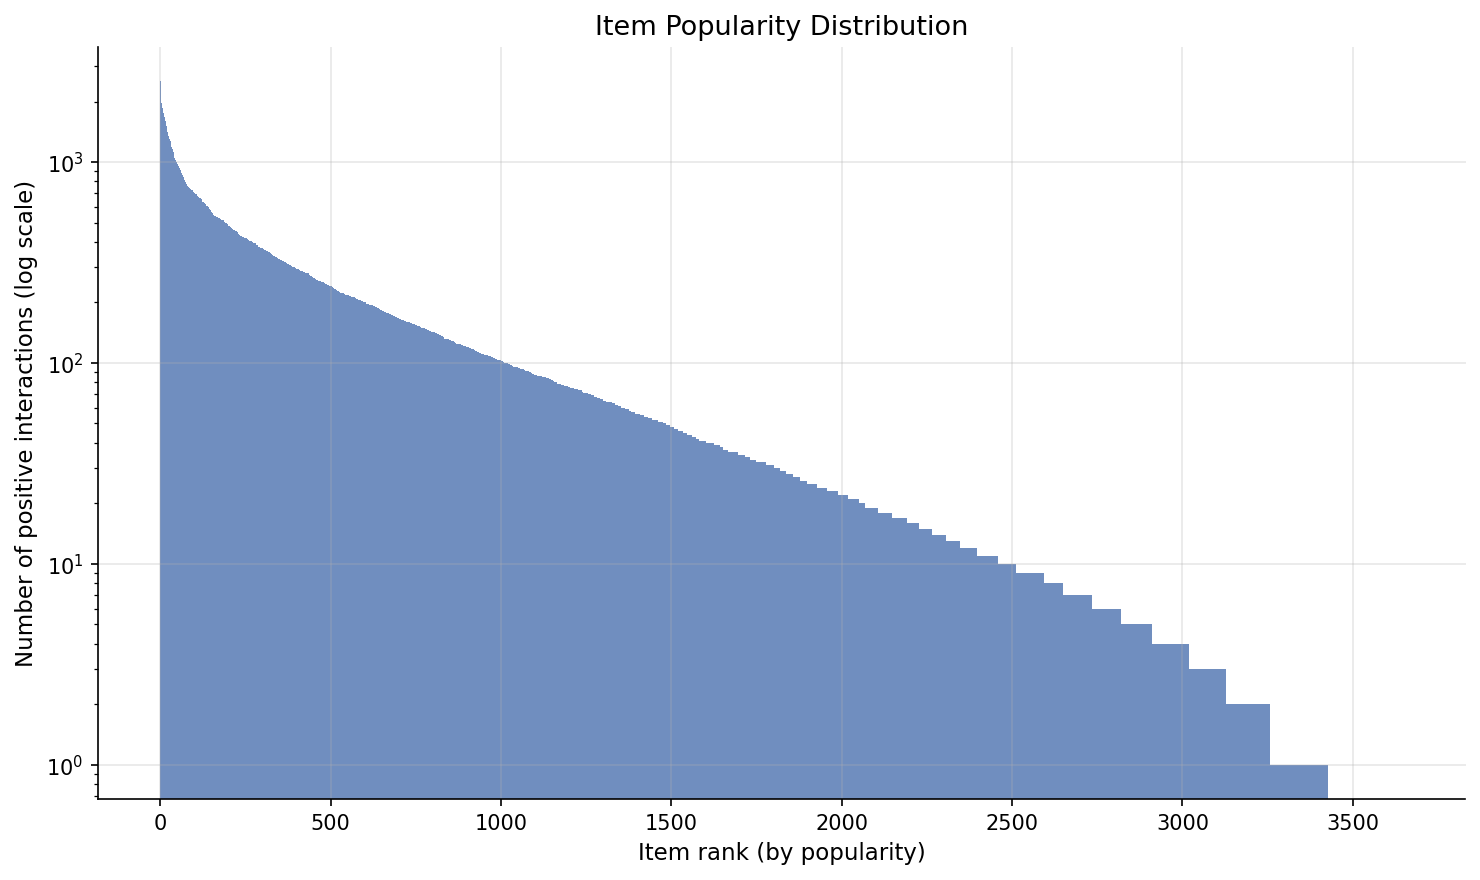

In [8]:
sorted_popularity = np.sort(popularity_model._item_popularity)[::-1]

plt.figure(figsize=FIGURE_SIZE_MEDIUM)
plt.bar(
    range(len(sorted_popularity)),
    sorted_popularity,
    width=1.0,
    color=COLOR_PRIMARY,
    alpha=0.8,
)
plt.yscale('log')
plt.xlabel('Item rank (by popularity)')
plt.ylabel('Number of positive interactions (log scale)')
plt.title('Item Popularity Distribution')
plt.tight_layout()
plt.show()

## 3. Item-Item Graph Propagation

### 3.1 Training

In [9]:
graph_model = ItemGraphRecommender()
graph_model.fit(train_data)

### 3.2 Evaluation

In [10]:
graph_recommendations = graph_model.recommend_for_eval(
    validation_users,
    k=TOP_K,
)

graph_ranking = compute_ranking_metrics(
    validation_positive,
    graph_recommendations,
    top_k=TOP_K,
)

graph_beyond = compute_beyond_accuracy_metrics(
    train_dataframe,
    graph_recommendations,
)

pd.DataFrame(
    list({**graph_ranking, **graph_beyond}.items()),
    columns=['metric', 'value'],
)

c:\Users\Mykyta\Projects\ucu-recsys\.venv\Lib\site-packages\recommenders\evaluation\python_evaluation.py:1435: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  avg_novelty = reco_item_novelty.agg({"product": "sum"})[0] / n_recommendations


,metric,value
0,ndcg,0.088429
1,map,0.042867
2,precision,0.072921
3,recall,0.063093
4,coverage,0.033160
5,novelty,8.406374


### 3.3 Co-occurrence degree distribution

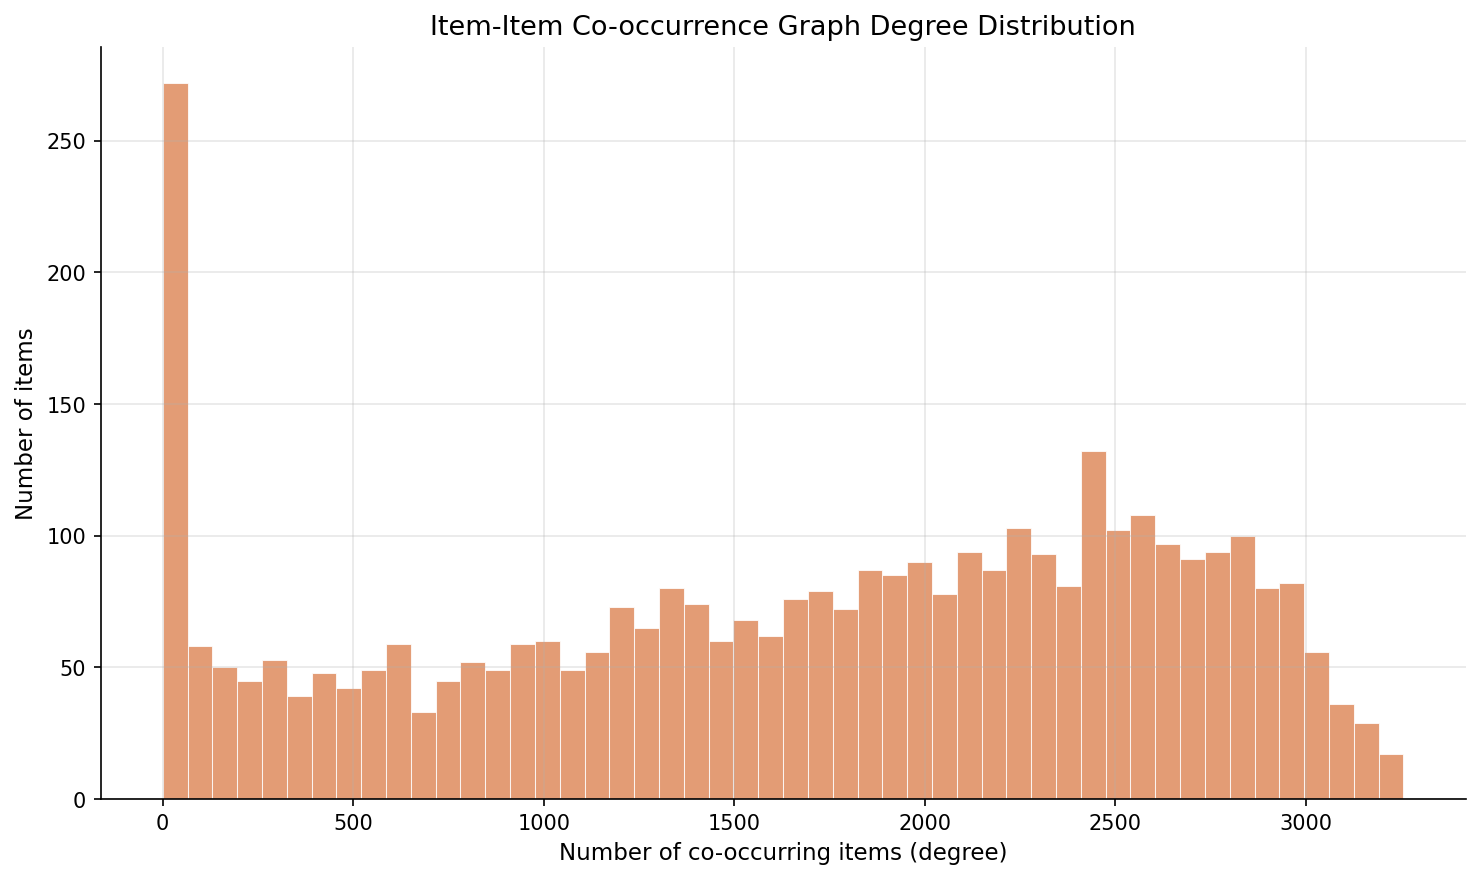

In [11]:
edge_counts_per_item = np.diff(graph_model.cooccurrence.indptr)

plt.figure(figsize=FIGURE_SIZE_MEDIUM)
plt.hist(
    edge_counts_per_item,
    bins=50,
    color=COLOR_SECONDARY,
    alpha=0.8,
    edgecolor='white',
    linewidth=0.5,
)
plt.xlabel('Number of co-occurring items (degree)')
plt.ylabel('Number of items')
plt.title('Item-Item Co-occurrence Graph Degree Distribution')
plt.tight_layout()
plt.show()

## 4. Personalized PageRank

### 4.1 Training

In [12]:
pagerank_model = PersonalizedPageRankRecommender(
    damping=PAGERANK_DAMPING,
    iterations=PAGERANK_ITERATIONS,
)
pagerank_model.fit(train_data)

In [13]:
pagerank_recommendations = pagerank_model.recommend_for_eval(
    validation_users,
    k=TOP_K,
)

pagerank_ranking = compute_ranking_metrics(
    validation_positive,
    pagerank_recommendations,
    top_k=TOP_K,
)

pagerank_beyond = compute_beyond_accuracy_metrics(
    train_dataframe,
    pagerank_recommendations,
)

pd.DataFrame(
    list({**pagerank_ranking, **pagerank_beyond}.items()),
    columns=['metric', 'value'],
)

c:\Users\Mykyta\Projects\ucu-recsys\.venv\Lib\site-packages\recommenders\evaluation\python_evaluation.py:1435: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  avg_novelty = reco_item_novelty.agg({"product": "sum"})[0] / n_recommendations


,metric,value
0,ndcg,0.078165
1,map,0.037472
2,precision,0.065733
3,recall,0.052353
4,coverage,0.030967
5,novelty,8.369707


## 5. Comparison

### 5.1 Ranking metrics

In [14]:
comparison_dataframe = pd.DataFrame([
    {'model': 'Popularity', **popularity_ranking},
    {'model': 'Item-Item Graph', **graph_ranking},
    {'model': 'Personalized PageRank', **pagerank_ranking},
])

comparison_dataframe

,model,ndcg,map,precision,recall
0,Popularity,0.076190,0.036509,0.064215,0.050457
1,Item-Item Graph,0.088429,0.042867,0.072921,0.063093
2,Personalized PageRank,0.078165,0.037472,0.065733,0.052353


### 5.2 NDCG comparison

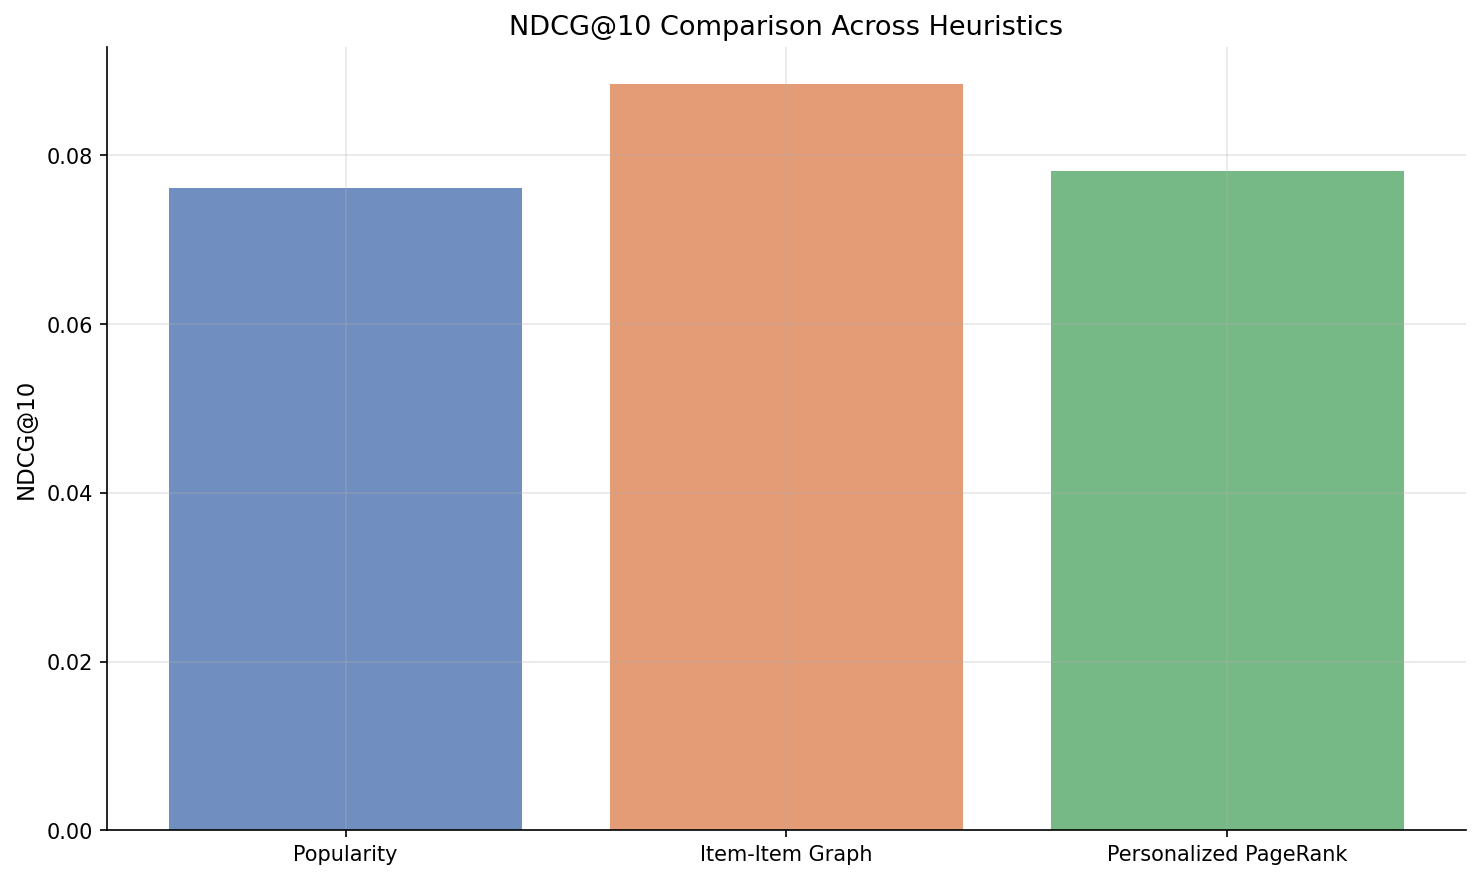

In [15]:
model_names = ['Popularity', 'Item-Item Graph', 'Personalized PageRank']
ndcg_values = [popularity_ranking['ndcg'], graph_ranking['ndcg'], pagerank_ranking['ndcg']]
bar_colors = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY]

plt.figure(figsize=FIGURE_SIZE_MEDIUM)
plt.bar(
    model_names,
    ndcg_values,
    color=bar_colors,
    alpha=0.8,
)
plt.ylabel('NDCG@10')
plt.title('NDCG@10 Comparison Across Heuristics')
plt.tight_layout()
plt.show()

### 5.3 Coverage comparison

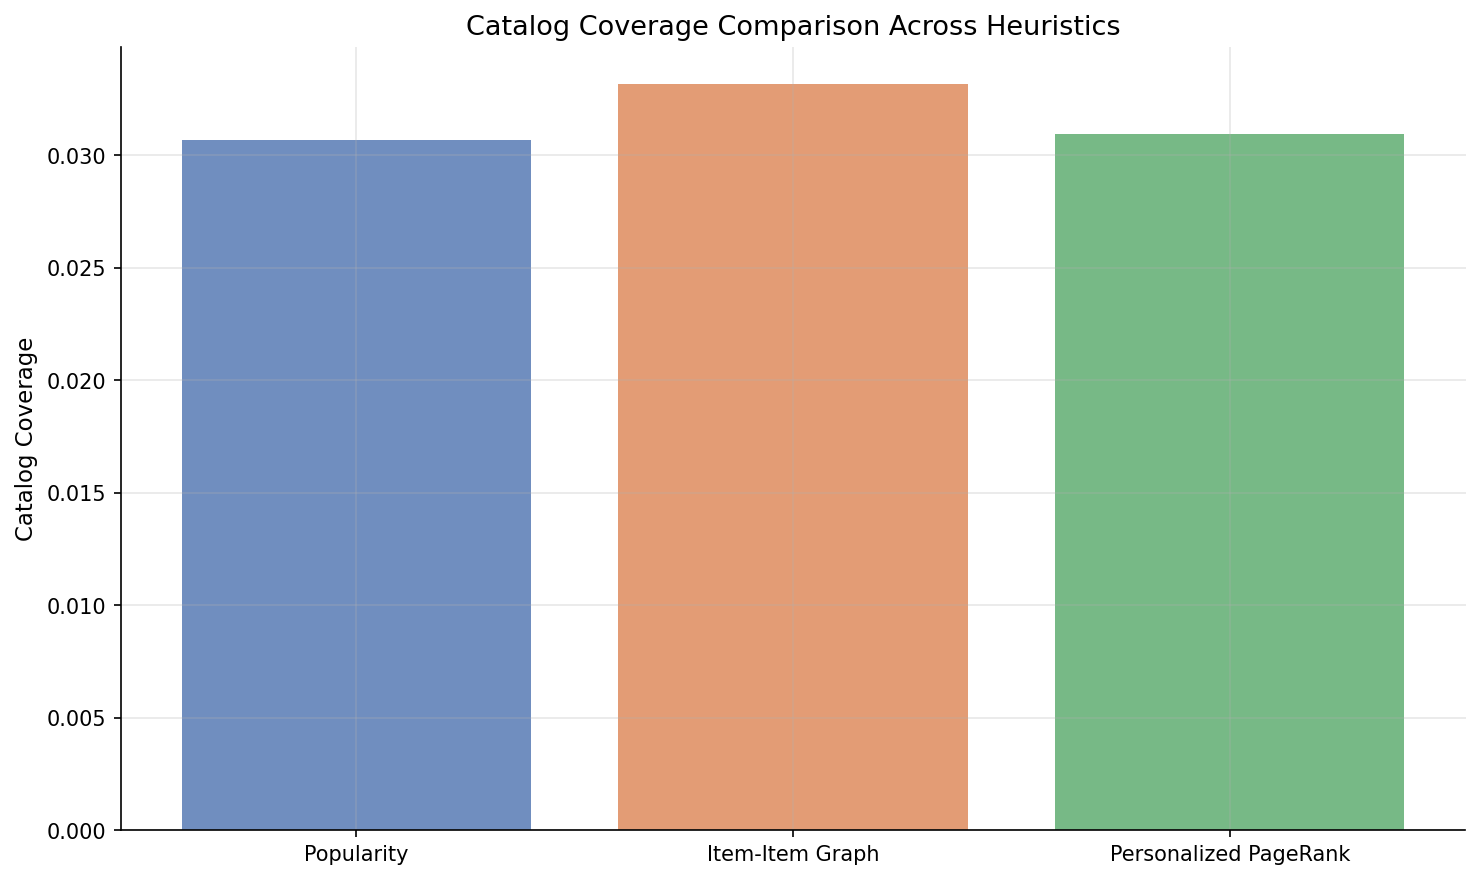

In [16]:
coverage_values = [popularity_beyond['coverage'], graph_beyond['coverage'], pagerank_beyond['coverage']]

plt.figure(figsize=FIGURE_SIZE_MEDIUM)
plt.bar(
    model_names,
    coverage_values,
    color=bar_colors,
    alpha=0.8,
)
plt.ylabel('Catalog Coverage')
plt.title('Catalog Coverage Comparison Across Heuristics')
plt.tight_layout()
plt.show()

### 5.4 Beyond-accuracy metrics

In [17]:
pd.DataFrame([
    {'model': 'Popularity', **popularity_beyond},
    {'model': 'Item-Item Graph', **graph_beyond},
    {'model': 'Personalized PageRank', **pagerank_beyond},
])

,model,coverage,novelty
0,Popularity,0.030693,8.365292
1,Item-Item Graph,0.033160,8.406374
2,Personalized PageRank,0.030967,8.369707


In [18]:
total_catalog_size = train_data.X_ui.shape[1]

unique_items_popularity = popularity_recommendations['item_id'].nunique()
unique_items_graph = graph_recommendations['item_id'].nunique()
unique_items_pagerank = pagerank_recommendations['item_id'].nunique()

pd.DataFrame({
    'model': ['Popularity', 'Item-Item Graph', 'Personalized PageRank'],
    'unique_items_recommended': [unique_items_popularity, unique_items_graph, unique_items_pagerank],
    'catalog_size': [total_catalog_size] * 3,
    'coverage_pct': [
        f"{unique_items_popularity / total_catalog_size:.1%}",
        f"{unique_items_graph / total_catalog_size:.1%}",
        f"{unique_items_pagerank / total_catalog_size:.1%}",
    ],
})

,model,unique_items_recommended,catalog_size,coverage_pct
0,Popularity,112,3649,3.1%
1,Item-Item Graph,121,3649,3.3%
2,Personalized PageRank,113,3649,3.1%


### 5.5 Head vs. tail user breakdown

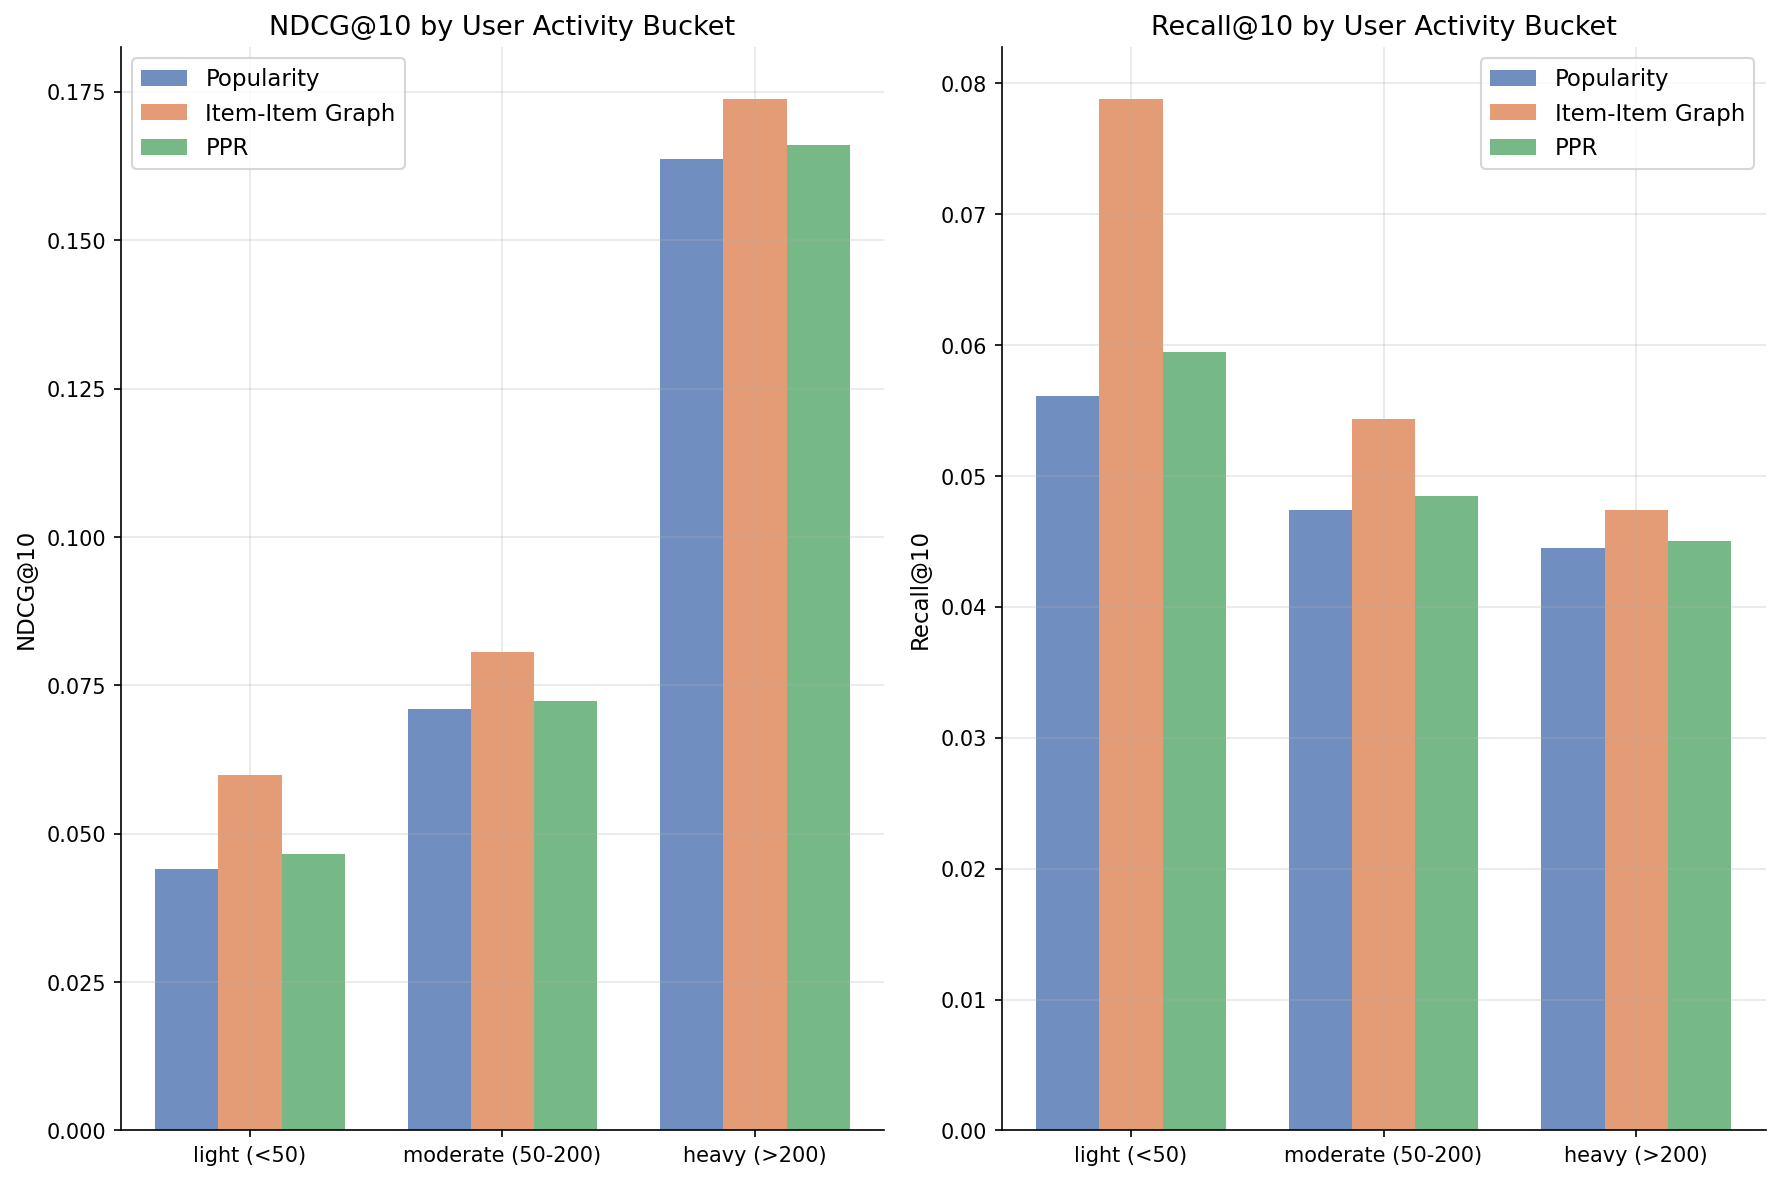

Per-bucket breakdown (NDCG / Recall):


,bucket,n_users,pop_ndcg,graph_ndcg,ppr_ndcg,pop_recall,graph_recall,ppr_recall
0,light (<50),2407,0.043984,0.059856,0.046555,0.056154,0.078844,0.059502
1,moderate (50-200),2489,0.071098,0.080663,0.072358,0.047408,0.054368,0.048479
2,heavy (>200),1031,0.163671,0.173882,0.165982,0.044514,0.047382,0.045013


In [19]:
train_user_activity = train_dataframe.groupby('user_id').size().rename('train_interactions')

activity_buckets = pd.cut(
    train_user_activity,
    bins=[0, 50, 200, np.inf],
    labels=['light (<50)', 'moderate (50-200)', 'heavy (>200)'],
)

user_bucket_map = activity_buckets.to_dict()

def per_bucket_ndcg(recommendations, validation_pos, bucket_map):
    rows = []
    for bucket_label in ['light (<50)', 'moderate (50-200)', 'heavy (>200)']:
        bucket_users = [u for u in validation_pos['user_id'].unique() if bucket_map.get(u) == bucket_label]
        if not bucket_users:
            continue
        bucket_val = validation_pos[validation_pos['user_id'].isin(bucket_users)]
        bucket_recs = recommendations[recommendations['user_id'].isin(bucket_users)]
        if len(bucket_recs) == 0:
            continue
        metrics = compute_ranking_metrics(bucket_val, bucket_recs, top_k=TOP_K)
        rows.append({'bucket': bucket_label, 'n_users': len(bucket_users), **metrics})
    return pd.DataFrame(rows)

pop_by_bucket = per_bucket_ndcg(popularity_recommendations, validation_positive, user_bucket_map)
graph_by_bucket = per_bucket_ndcg(graph_recommendations, validation_positive, user_bucket_map)
ppr_by_bucket = per_bucket_ndcg(pagerank_recommendations, validation_positive, user_bucket_map)

bucket_labels = pop_by_bucket['bucket'].values
x = np.arange(len(bucket_labels))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

axes[0].bar(x - width, pop_by_bucket['ndcg'], width, label='Popularity', color=COLOR_PRIMARY, alpha=0.8)
axes[0].bar(x, graph_by_bucket['ndcg'], width, label='Item-Item Graph', color=COLOR_SECONDARY, alpha=0.8)
axes[0].bar(x + width, ppr_by_bucket['ndcg'], width, label='PPR', color=COLOR_TERTIARY, alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(bucket_labels)
axes[0].set_ylabel('NDCG@10')
axes[0].set_title('NDCG@10 by User Activity Bucket')
axes[0].legend()

axes[1].bar(x - width, pop_by_bucket['recall'], width, label='Popularity', color=COLOR_PRIMARY, alpha=0.8)
axes[1].bar(x, graph_by_bucket['recall'], width, label='Item-Item Graph', color=COLOR_SECONDARY, alpha=0.8)
axes[1].bar(x + width, ppr_by_bucket['recall'], width, label='PPR', color=COLOR_TERTIARY, alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(bucket_labels)
axes[1].set_ylabel('Recall@10')
axes[1].set_title('Recall@10 by User Activity Bucket')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Per-bucket breakdown (NDCG / Recall):")
summary = pop_by_bucket[['bucket', 'n_users']].copy()
summary['pop_ndcg'] = pop_by_bucket['ndcg'].values
summary['graph_ndcg'] = graph_by_bucket['ndcg'].values
summary['ppr_ndcg'] = ppr_by_bucket['ndcg'].values
summary['pop_recall'] = pop_by_bucket['recall'].values
summary['graph_recall'] = graph_by_bucket['recall'].values
summary['ppr_recall'] = ppr_by_bucket['recall'].values
summary